# Проект 3. A/B-тест стоимости премиум-подписки

**Задача:** определить, был ли успешен эксперимент с изменением стоимости
премиум-подписки в дейтинг-приложении. Данные: шесть предоставленных CSV-файлов,
группы `test`, `control_1`, `control_2`.

**Результат:** успех эксперимента не подтверждён. Выручка на пользователя
в тесте выше объединённого контроля на 2,07%, но различие статистически
незначимо. Конверсия в оплату снизилась с 4,39% до 3,39%.
По этим данным внедрение изменения не рекомендуется.

Для повторного запуска поместите ноутбук и шесть исходных CSV в одну папку
либо положите CSV в подпапку `data`, затем выполните все ячейки сверху вниз.
Используются Python, pandas, NumPy, SciPy и Matplotlib.

## 1. Метрики и схема анализа

Единица анализа — **пользователь**, а не платёж: один человек может платить
несколько раз. Неплатящие пользователи входят в знаменатель и имеют нулевую
выручку. Денежные значения приведены в нормированных единицах исходных данных.

| Метрика | Расчёт | Назначение |
|---|---|---|
| ARPU | Сумма `total_revenue` / число пользователей | Основная метрика успеха |
| CR в оплату | Пользователи с `total_revenue > 0` / все пользователи | Проверка влияния на число покупателей |
| CR premium | Покупатели `premium_no_trial` или `trial_premium` / все пользователи | Покупка премиального продукта |
| CR premium_no_trial | Покупатели этого продукта / все пользователи | Прямая покупка премиума |
| CR trial_premium | Покупатели этого продукта / все пользователи | Покупка продукта с меткой trial |
| ARPPU | Выручка / число платящих пользователей | Диагностика изменения состава покупателей |
| Premium ARPU | Выручка двух premium-продуктов / все пользователи | Диагностика выручки подписки |

Для основной метрики: H₀ — средние ARPU теста и контроля равны;
H₁ — различаются. Используется двусторонний тест Уэлча, α = 0,05;
положительный эффект дополнительно проверяется пользовательским бутстрепом.
Успех требует подтверждённого роста ARPU без ухудшения ключевой конверсии.

Основное сравнение — `test` с объединением двух контрольных групп,
взвешенным по числу пользователей. Это опирается на условие об одинаковом
контрольном варианте. A/A-проверка служит диагностикой и не доказывает
эквивалентность контролей. Сравнения с каждым контролем показаны отдельно.

Для шести дополнительных метрик применяется поправка Холма в одной семье
проверок. План анализа составлен по готовой выгрузке: это ретроспективная
оценка, а не заранее зарегистрированный протокол эксперимента.

In [1]:
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

GROUPS = ['control_1', 'control_2', 'test']
ALPHA = 0.05
SEED = 20260910
BOOTSTRAP_ITERATIONS = 50_000
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 80)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.dpi': 120, 'savefig.dpi': 150,
})

def resolve_csv(folder, kind, group):
    candidates = [folder / f'Проект_3_{kind}_{group}.csv',
                  folder / f'{kind}_{group}.csv']
    return next((p for p in candidates if p.is_file()), None)

folders = [Path('.'), Path('data'), Path('upload'), Path('../upload')]
DATA_DIR = next((p for p in folders if all(
    resolve_csv(p, kind, g) for kind in ['users', 'transactions'] for g in GROUPS
)), None)
if DATA_DIR is None:
    raise FileNotFoundError('Поместите шесть CSV рядом с ноутбуком или в папку data.')

raw_users, raw_transactions, input_rows = {}, {}, []
for g in GROUPS:
    for kind, storage in [('users', raw_users), ('transactions', raw_transactions)]:
        path = resolve_csv(DATA_DIR, kind, g)
        df = pd.read_csv(path, sep=';')
        storage[g] = df
        input_rows.append({
            'Файл': path.name, 'Строк': len(df), 'Столбцов': df.shape[1],
            'Без uid': int(df.uid.isna().sum()),
            'Повторы целых строк': int(df.duplicated().sum())
        })
display(pd.DataFrame(input_rows))

,Файл,Строк,Столбцов,Без uid,Повторы целых строк
0,Проект_3_users_control_1.csv,4340,13,0,0
1,Проект_3_transactions_control_1.csv,1007,8,630,650
2,Проект_3_users_control_2.csv,4264,13,0,0
3,Проект_3_transactions_control_2.csv,328,8,0,5
4,Проект_3_users_test.csv,4308,13,0,0
5,Проект_3_transactions_test.csv,273,8,0,7


## 2. Проверка и подготовка данных

В `transactions_control_1` обнаружены 630 строк без идентификатора,
страны, выручки и продукта; вместо дат в них записано `NaT`. Это пустые
строки выгрузки, их удаляем. После этого остаётся 33 полных повтора:
21 в первом контроле, 5 во втором и 7 в тесте.

Повторы **сохраняем в основном анализе**: в большинстве случаев они входят
в `users.total_revenue`. Поле `payment_id` принимает несколько повторяющихся
значений и не является уникальным ключом операции. Без такого ключа нельзя
установить, отражают одинаковые строки повторные платежи или ошибку выгрузки.
Расчёт без повторов будет отдельной проверкой устойчивости.

In [2]:
users_all = pd.concat([raw_users[g].assign(group=g) for g in GROUPS], ignore_index=True)
transactions_all = pd.concat(
    [raw_transactions[g].assign(group=g) for g in GROUPS], ignore_index=True
)

empty = transactions_all.uid.isna()
assert transactions_all.loc[empty, ['country', 'revenue', 'payment_id',
                                  'from_page', 'product_type']].isna().all().all()
assert transactions_all.loc[empty, ['joined_at', 'paid_at']].isin(['NaT']).all().all()
transactions_all = transactions_all.loc[~empty].copy()
transactions_all[['uid', 'payment_id', 'revenue']] = transactions_all[
    ['uid', 'payment_id', 'revenue']].astype('int64')

assert users_all.uid.is_unique, 'Повтор пользователя внутри или между группами.'
assert users_all[['uid', 'country', 'total_revenue']].notna().all().all()
assert (users_all.total_revenue >= 0).all()
assert (transactions_all.revenue > 0).all()
assert transactions_all.notna().all().all()
assert users_all.attraction_coeff.between(0, 1000).all()
assert users_all.gender.isin([0, 1]).all()

linked = transactions_all.merge(
    users_all[['uid', 'group', 'country']], on='uid', how='left',
    suffixes=('_payment', '_user'), validate='many_to_one', indicator=True
)
assert linked['_merge'].eq('both').all()
assert linked.group_payment.eq(linked.group_user).all()
assert linked.country_payment.eq(linked.country_user).all()

missing = users_all.groupby('group')[
    ['coins', 'visit_days', 'was_premium', 'is_premium']
].agg(lambda s: s.isna().sum()).reindex(GROUPS)
display(missing.rename_axis('Пропуски в users'))
display(transactions_all.groupby('group').agg(
    rows=('uid', 'size'), users=('uid', 'nunique'),
    payment_id_values=('payment_id', 'nunique')
).reindex(GROUPS))
print('Пересечений пользователей между группами, платежей без пользователя')
print('и расхождений страны/группы между таблицами не обнаружено.')

,coins,visit_days,was_premium,is_premium
Пропуски в users,,,,
control_1,4280,1324,3904,4148
control_2,4203,1364,3853,4073
test,4259,1330,3900,4151


,rows,users,payment_id_values
group,,,
control_1,377,193,7
control_2,328,187,6
test,273,146,6


Пересечений пользователей между группами, платежей без пользователя
и расхождений страны/группы между таблицами не обнаружено.


Пропуски в `coins`, `visit_days`, `was_premium`, `is_premium` не заполняем
произвольно: для выбранных метрик эти поля не нужны. Наличие премиум-статуса
не используем как конверсию в оплату, поскольку он может включать пробный период.
Возраст достигает 99 лет; без доказательства ошибки таких пользователей
не удаляем. Поведенческие показатели могут изменяться из-за эксперимента,
поэтому по ним не фильтруем выборку и не оцениваем исходный баланс.

In [3]:
for col in ['joined_at', 'paid_at']:
    transactions_all[col + '_parsed'] = pd.to_datetime(
        transactions_all[col], format='%Y-%m-%d %H:%M:%S', errors='coerce'
    )
    assert transactions_all[col + '_parsed'].notna().all()

# Год регистрации не зависит от неоднозначного порядка месяца и дня.
# 2017 — год основной когорты выгрузки, а не известная дата старта A/B-теста.
cohort_year = int(transactions_all.joined_at_parsed.dt.year.mode().iloc[0])
historical = transactions_all.joined_at_parsed.dt.year.lt(cohort_year)
historical_ids = transactions_all.loc[historical, 'uid'].unique()
display(transactions_all.loc[historical, [
    'uid', 'group', 'joined_at', 'paid_at', 'revenue', 'from_page'
]])

users = users_all.loc[~users_all.uid.isin(historical_ids)].copy()
transactions = transactions_all.loc[~transactions_all.uid.isin(historical_ids)].copy()
print('Исключены исторические пользователи:', historical_ids.tolist())
print('Пользователей в анализе:', len(users))

,uid,group,joined_at,paid_at,revenue,from_page
65,960936960,control_1,2015-01-19 11:49:00,2016-12-14 17:30:00,26,refund_VP
101,960936960,control_1,2015-01-19 11:49:00,2016-12-14 17:35:00,637,refung_AP
224,960936960,control_1,2015-01-19 11:49:00,2016-12-14 16:16:00,143,refund_WP


Исключены исторические пользователи: [960936960]
Пользователей в анализе: 12911


Пользователь `960936960` из `control_1` зарегистрирован в 2015 году,
его три операции относятся к 2016 году и имеют метки возвратов.
Он не соответствует условию о новых пользователях основной когорты 2017 года.
Исключаем его из обеих таблиц. В `users` у него 26 единиц выручки,
в транзакциях — 806. Сценарий с его сохранением также проверяется ниже.

В исходных датах 162 платежа предшествуют регистрации. У всех неоднозначных
дат 2017 года с днём не более 12 день равен 11. Это согласуется с ошибочной
перестановкой дня и месяца при преобразовании ноябрьских дат.
Ниже проверяется такая **гипотеза восстановления**, исходные даты сохраняются.
Это не подтверждённое исправление источника и не основание для отбора покупателей.

In [4]:
def proposed_date_fix(series):
    result = series.copy()
    ambiguous = result.dt.year.eq(cohort_year) & result.dt.day.le(12)
    result.loc[ambiguous] = pd.to_datetime(
        result.loc[ambiguous].dt.strftime('%Y-%d-%m %H:%M:%S'),
        format='%Y-%m-%d %H:%M:%S'
    )
    return result

for col in ['joined_at', 'paid_at']:
    transactions[col + '_assumed'] = proposed_date_fix(transactions[col + '_parsed'])

date_rows = []
for g in GROUPS:
    d = transactions.loc[transactions.group.eq(g)]
    date_rows.append({
        'Группа': g,
        'Оплата до регистрации, исходные даты': int((d.paid_at_parsed < d.joined_at_parsed).sum()),
        'После гипотетического исправления': int((d.paid_at_assumed < d.joined_at_assumed).sum()),
        'Регистрация от': str(d.joined_at_assumed.min()),
        'Регистрация до': str(d.joined_at_assumed.max()),
        'Оплата до': str(d.paid_at_assumed.max()),
    })
display(pd.DataFrame(date_rows).set_index('Группа'))

,"Оплата до регистрации, исходные даты",После гипотетического исправления,Регистрация от,Регистрация до,Оплата до
Группа,,,,,
control_1,55,0,2017-10-14 12:03:00,2017-11-09 22:48:00,2017-11-15 09:28:00
control_2,60,0,2017-10-14 00:54:00,2017-11-10 11:45:00,2017-11-15 02:15:00
test,47,0,2017-10-14 00:58:00,2017-11-10 10:20:00,2017-11-15 09:31:00


После пробной перестановки все платежи идут после регистрации;
регистрации плательщиков укладываются в 14 октября — 10 ноября 2017 года,
платежи — в 14 октября — 15 ноября. Однако даты регистрации **неплатящих**
пользователей, время включения в тест и конец наблюдения отсутствуют.
Поэтому корректно сравнить ARPU за одинаковые 7/14/30 дней, удержание и LTV
невозможно. Основной расчёт использует итоговую выручку без фильтрации по датам;
его причинная интерпретация предполагает сопоставимое окно сбора данных в группах.

In [5]:
transaction_columns = list(raw_transactions['test'].columns) + ['group']
tx_revenue = transactions.groupby('uid').revenue.sum()
reconciliation = users[['uid', 'group', 'total_revenue']].copy()
reconciliation['transactions_revenue'] = reconciliation.uid.map(tx_revenue).fillna(0)
reconciliation['difference'] = (
    reconciliation.transactions_revenue - reconciliation.total_revenue
)
mismatches = reconciliation.loc[reconciliation.difference.ne(0)]
display(mismatches.reset_index(drop=True))

audit_rows = []
for g in GROUPS:
    u = users.loc[users.group.eq(g)]
    t = transactions.loc[transactions.group.eq(g)]
    td = t.drop_duplicates(subset=transaction_columns)
    s_raw = u.uid.map(t.groupby('uid').revenue.sum()).fillna(0)
    s_dedup = u.uid.map(td.groupby('uid').revenue.sum()).fillna(0)
    audit_rows.append({
        'Группа': g, 'Полные повторы': int(t.duplicated(subset=transaction_columns).sum()),
        'Расхождения users / transactions': int(s_raw.ne(u.total_revenue).sum()),
        'Расхождения после удаления повторов': int(s_dedup.ne(u.total_revenue).sum()),
    })
display(pd.DataFrame(audit_rows).set_index('Группа'))

top_users = users.nlargest(5, 'total_revenue')[['uid', 'group', 'country', 'total_revenue']].copy()
top_users['Доля выручки своей группы, %'] = top_users.total_revenue / top_users.group.map(
    users.groupby('group').total_revenue.sum()) * 100
display(top_users.reset_index(drop=True))

,uid,group,total_revenue,transactions_revenue,difference
0,892355163,control_1,0,"30,264.0000","30,264.0000"
1,892275462,test,14885,"58,968.0000","44,083.0000"


,Полные повторы,Расхождения users / transactions,Расхождения после удаления повторов
Группа,,,
control_1,21,1,11
control_2,5,0,5
test,7,1,6


,uid,group,country,total_revenue,"Доля выручки своей группы, %"
0,892333905,control_1,Italy,486330,18.8409
1,891178380,test,Spain,129870,5.6445
2,892038759,test,United Arab Emirates,123565,5.3705
3,892236423,test,United States of America,95823,4.1647
4,891778551,control_2,United Arab Emirates,81796,4.2592


Остаются два несоответствия: `892355163` — 0 в `users` против 30 264
в платежах; `892275462` — 14 885 против 58 968. Причину по файлам установить
нельзя. В основном анализе ARPU и конверсии используем `users.total_revenue`
как явно предоставленный пользовательский итог. Продуктовые показатели
считаем по транзакциям и обозначаем отдельно; спорные платежи относятся к `other_type`.

Максимальная выручка у `892333905`: 486 330, или 18,84% выручки `control_1`.
Она полностью согласуется с суммой его транзакций. Высокое значение само по себе
не доказывает ошибку: сохраняем пользователя и отдельно проверяем влияние
его исключения. Удаление только одного крупного покупателя не является
основным способом обработки данных.

## 3. Сопоставимость групп и A/A-проверка

Проверяем численность групп при предполагаемом распределении 1:1:1,
возраст, пол и страну. Для стран редкие категории объединяем в «Другие»
по общему числу пользователей менее 60, без использования результатов оплаты.
Точный план распределения в условии отсутствует, поэтому SRM-проверка условна.

In [6]:
def welch_result(x, y, alpha=ALPHA):
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    v1, v0 = x.var(ddof=1) / len(x), y.var(ddof=1) / len(y)
    se = np.sqrt(v1 + v0)
    df = (v1 + v0)**2 / (v1**2 / (len(x)-1) + v0**2 / (len(y)-1))
    delta = x.mean() - y.mean()
    margin = stats.t.ppf(1-alpha/2, df) * se
    return {'test': x.mean(), 'control': y.mean(), 'delta': delta,
            'lift_pct': (x.mean()/y.mean()-1)*100,
            'ci_low': delta-margin, 'ci_high': delta+margin,
            'p': float(stats.ttest_ind(x, y, equal_var=False).pvalue)}

def holm_adjust(pvalues):
    p = np.asarray(pvalues, dtype=float)
    order = np.argsort(p)
    sorted_adj = np.maximum.accumulate(p[order] * np.arange(len(p), 0, -1))
    result = np.empty_like(p)
    result[order] = np.minimum(sorted_adj, 1)
    return result

users['payer'] = users.total_revenue.gt(0)
product_sets = {
    'premium': ['premium_no_trial', 'trial_premium'],
    'direct': ['premium_no_trial'],
    'trial': ['trial_premium'],
}
for name, products in product_sets.items():
    subset = transactions.loc[transactions.product_type.isin(products)]
    users[name] = users.uid.isin(subset.uid.unique())
    users[name + '_revenue'] = users.uid.map(subset.groupby('uid').revenue.sum()).fillna(0)

country_counts = users.country.value_counts()
country_binned = users.country.where(users.country.map(country_counts).ge(60), 'Другие')
country_table = pd.crosstab(country_binned, users.group)
country_test = stats.chi2_contingency(country_table)
assert country_test.expected_freq.min() >= 5
balance = pd.DataFrame([
    ['Численность 1:1:1 (SRM)', stats.chisquare(users.group.value_counts()).pvalue],
    ['Возраст (ANOVA)', stats.f_oneway(*(users.loc[users.group.eq(g), 'age'] for g in GROUPS)).pvalue],
    ['Пол (χ²)', stats.chi2_contingency(pd.crosstab(users.gender, users.group)).pvalue],
    ['Страна (χ²)', country_test.pvalue],
], columns=['Проверка', 'p-value'])
display(users.groupby('group').agg(
    users=('uid', 'size'), age_mean=('age', 'mean'), age_median=('age', 'median'),
    gender_1_share=('gender', 'mean')
).reindex(GROUPS))
display(balance)

test = users.loc[users.group.eq('test')]
control = users.loc[users.group.ne('test')]
c1 = users.loc[users.group.eq('control_1')]
c2 = users.loc[users.group.eq('control_2')]
aa = pd.DataFrame([
    {'Метрика': 'ARPU', 'control_1': c1.total_revenue.mean(), 'control_2': c2.total_revenue.mean(),
     'p-value': welch_result(c1.total_revenue, c2.total_revenue)['p']},
    {'Метрика': 'CR оплаты, %', 'control_1': c1.payer.mean()*100, 'control_2': c2.payer.mean()*100,
     'p-value': stats.fisher_exact([[c1.payer.sum(), (~c1.payer).sum()],
                                   [c2.payer.sum(), (~c2.payer).sum()]]).pvalue}
])
display(aa)

,users,age_mean,age_median,gender_1_share
group,,,,
control_1,4339,32.0959,30.0000,0.9581
control_2,4264,32.0462,30.0000,0.9543
test,4308,31.8893,30.0000,0.9531


,Проверка,p-value
0,Численность 1:1:1 (SRM),0.7189
1,Возраст (ANOVA),0.6188
2,Пол (χ²),0.5090
3,Страна (χ²),0.6760


,Метрика,control_1,control_2,p-value
0,ARPU,594.8931,450.3841,0.2625
1,"CR оплаты, %",4.4019,4.3856,1.0000


Значимых расхождений по проверенным исходным признакам и численности
не обнаружено. Контроли различаются по ARPU на уровне точечной оценки,
но A/A-тест даёт p = 0,262; для конверсии p = 1,000. Это не доказывает
равенство групп и не заменяет проверку системы рандомизации.

## 4. Метрики эксперимента

Пользователя, оплатившего оба premium-продукта, учитываем один раз
в общей CR premium. ARPPU описывает тех, кто заплатил уже после воздействия
эксперимента: его рост сам по себе не доказывает пользу новой цены.

In [7]:
def metrics(d):
    return pd.Series({
        'Пользователи': len(d), 'Плательщики': int(d.payer.sum()),
        'Выручка': d.total_revenue.sum(), 'ARPU': d.total_revenue.mean(),
        'CR оплаты, %': d.payer.mean()*100,
        'ARPPU': d.loc[d.payer, 'total_revenue'].mean(),
        'CR premium, %': d.premium.mean()*100,
        'CR premium_no_trial, %': d.direct.mean()*100,
        'CR trial_premium, %': d.trial.mean()*100,
        'Premium ARPU': d.premium_revenue.mean(),
    })

metrics_table = pd.DataFrame({g: metrics(users.loc[users.group.eq(g)]) for g in GROUPS})
metrics_table['control_pool'] = metrics(control)
display(metrics_table.round(4))

# Проверка разложения ARPU = CR оплаты × ARPPU.
for d in [c1, c2, test, control]:
    assert np.isclose(d.total_revenue.mean(), d.payer.mean() * d.loc[d.payer, 'total_revenue'].mean())

product_table = transactions.groupby(['product_type', 'group']).agg(
    revenue=('revenue', 'sum'), buyers=('uid', 'nunique'),
    median_payment=('revenue', 'median')
).reset_index()
product_table['revenue_per_user'] = product_table.revenue / product_table.group.map(users.group.value_counts())
display(product_table.pivot(index='product_type', columns='group',
                            values=['buyers', 'revenue_per_user', 'median_payment']).round(2))

,control_1,control_2,test,control_pool
Пользователи,"4,339.0000","4,264.0000","4,308.0000","8,603.0000"
Плательщики,191.0000,187.0000,146.0000,378.0000
Выручка,"2,581,241.0000","1,920,438.0000","2,300,818.0000","4,501,679.0000"
ARPU,594.8931,450.3841,534.0803,523.2685
"CR оплаты, %",4.4019,4.3856,3.3890,4.3938
ARPPU,"13,514.3508","10,269.7219","15,759.0274","11,909.2037"
"CR premium, %",3.8258,3.6351,2.9480,3.7313
"CR premium_no_trial, %",2.2816,2.3921,1.5552,2.3364
"CR trial_premium, %",1.5441,1.2430,1.4160,1.3949
Premium ARPU,357.6813,325.7012,373.9341,341.8306


buyers                   revenue_per_user                    median_payment                        
group            control_1 control_2    test        control_1 control_2     test      control_1   control_2        test
product_type                                                                                                           
coins              65.0000   69.0000 52.0000         200.9500   94.4900 131.4200     3,913.0000  1,261.0000  3,536.0000
other_type         29.0000   33.0000 19.0000          43.2400   30.1900  38.9500     3,783.0000  2,730.0000  2,756.0000
premium_no_trial   99.0000  102.0000 67.0000         179.5900  174.6700 188.1900     6,292.0000  6,292.0000  8,021.0000
trial_premium      67.0000   53.0000 61.0000         178.0900  151.0300 185.7500    12,402.0000 12,727.0000 12,746.5000

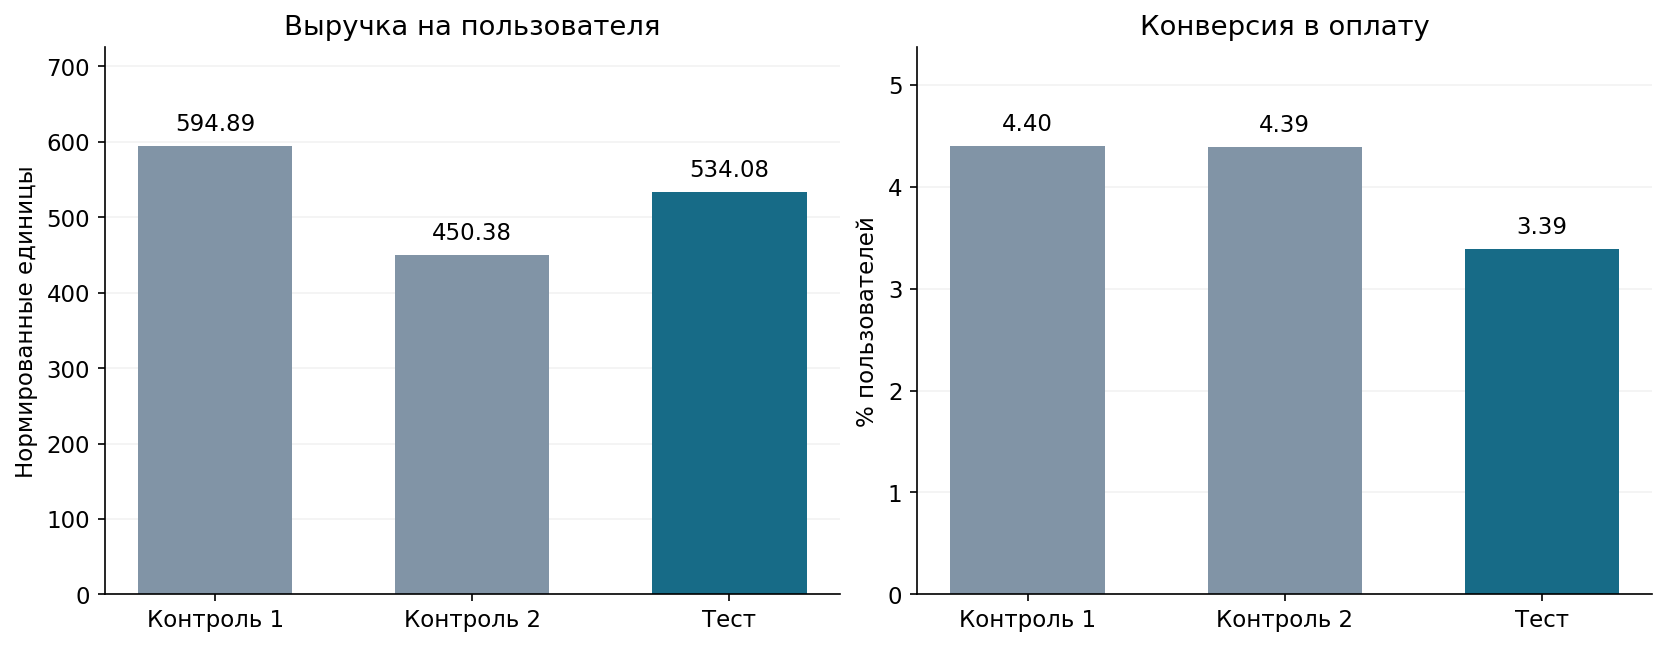

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
palette = ['#8194a6', '#8194a6', '#176b87']
labels = ['Контроль 1', 'Контроль 2', 'Тест']
arpu = [users.loc[users.group.eq(g), 'total_revenue'].mean() for g in GROUPS]
cr = [users.loc[users.group.eq(g), 'payer'].mean()*100 for g in GROUPS]
for ax, values, title, ylabel in [
    (axes[0], arpu, 'Выручка на пользователя', 'Нормированные единицы'),
    (axes[1], cr, 'Конверсия в оплату', '% пользователей')
]:
    bars = ax.bar(labels, values, color=palette, width=0.6)
    ax.bar_label(bars, labels=[f'{v:.2f}' for v in values], padding=5)
    ax.set(title=title, ylabel=ylabel, ylim=(0, max(values)*1.22))
    ax.grid(axis='y', alpha=.16)
    ax.set_axisbelow(True)
plt.show()

В тесте выше доход на плательщика, но меньше самих плательщиков.
Медиана платежа `premium_no_trial` составляет 8 021 против 6 292 в каждом
контроле. Это описание наблюдаемого состава платежей, а не оценка точного
процента изменения тарифа: страны, состав покупателей и варианты продукта
могут различаться. Ценового справочника в файлах нет.

## 5. Статистическая проверка

Выручка имеет много нулей и длинный правый хвост. Тест Уэлча сравнивает
средние и не требует равенства дисперсий. Его приближение проверяем
непараметрическим бутстрепом на уровне пользователей. Проверка нормальности
и тест Манна—Уитни не нужны для принятия решения о равенстве средних ARPU.

In [9]:
primary = welch_result(test.total_revenue, control.total_revenue)
display(pd.DataFrame([primary]).rename(columns={
    'test': 'ARPU test', 'control': 'ARPU control_pool', 'delta': 'Разность',
    'lift_pct': 'Изменение, %', 'ci_low': '95% ДИ, низ',
    'ci_high': '95% ДИ, верх', 'p': 'p-value'
}))

def bootstrap_means(values, rng, iterations=BOOTSTRAP_ITERATIONS, batch=1000):
    values = np.asarray(values, dtype=float)
    unique, counts = np.unique(values, return_counts=True)
    probabilities = counts / len(values)
    output = np.empty(iterations)
    for start in range(0, iterations, batch):
        size = min(batch, iterations-start)
        # Мультиномиальные частоты дают тот же обычный пользовательский
        # бутстреп, включая нулевую выручку, без огромной матрицы индексов.
        sampled_counts = rng.multinomial(len(values), probabilities, size=size)
        output[start:start+size] = sampled_counts @ unique / len(values)
    return output

rng = np.random.default_rng(SEED)
boot_test = bootstrap_means(test.total_revenue, rng)
boot_control = bootstrap_means(control.total_revenue, rng)
boot_difference = boot_test - boot_control
boot_relative = (boot_test/boot_control-1)*100
bootstrap_abs_ci = np.quantile(boot_difference, [ALPHA/2, 1-ALPHA/2])
bootstrap_rel_ci = np.quantile(boot_relative, [ALPHA/2, 1-ALPHA/2])
display(pd.DataFrame({
    'Показатель': ['Разность ARPU', 'Относительное изменение ARPU, %'],
    '95% ДИ, низ': [bootstrap_abs_ci[0], bootstrap_rel_ci[0]],
    '95% ДИ, верх': [bootstrap_abs_ci[1], bootstrap_rel_ci[1]],
}))

,ARPU test,ARPU control_pool,Разность,"Изменение, %","95% ДИ, низ","95% ДИ, верх",p-value
0,534.0803,523.2685,10.8118,2.0662,-171.4847,193.1083,0.9075


,Показатель,"95% ДИ, низ","95% ДИ, верх"
0,Разность ARPU,-177.9869,189.2759
1,"Относительное изменение ARPU, %",-28.2562,41.8087


**Основная метрика:** ARPU = 534,08 в тесте и 523,27 в объединённом контроле.
Разность +10,81, или +2,07%; p = 0,907. Доверительный интервал Уэлча:
от −171,48 до +193,11. Бутстреп даёт интервал разности от −177,99 до +189,28
и относительного эффекта от −28,26% до +41,81%.

Статистических оснований признать рост ARPU нет. Это **не доказательство
нулевого эффекта**: данные допускают как ухудшение, так и заметное улучшение.

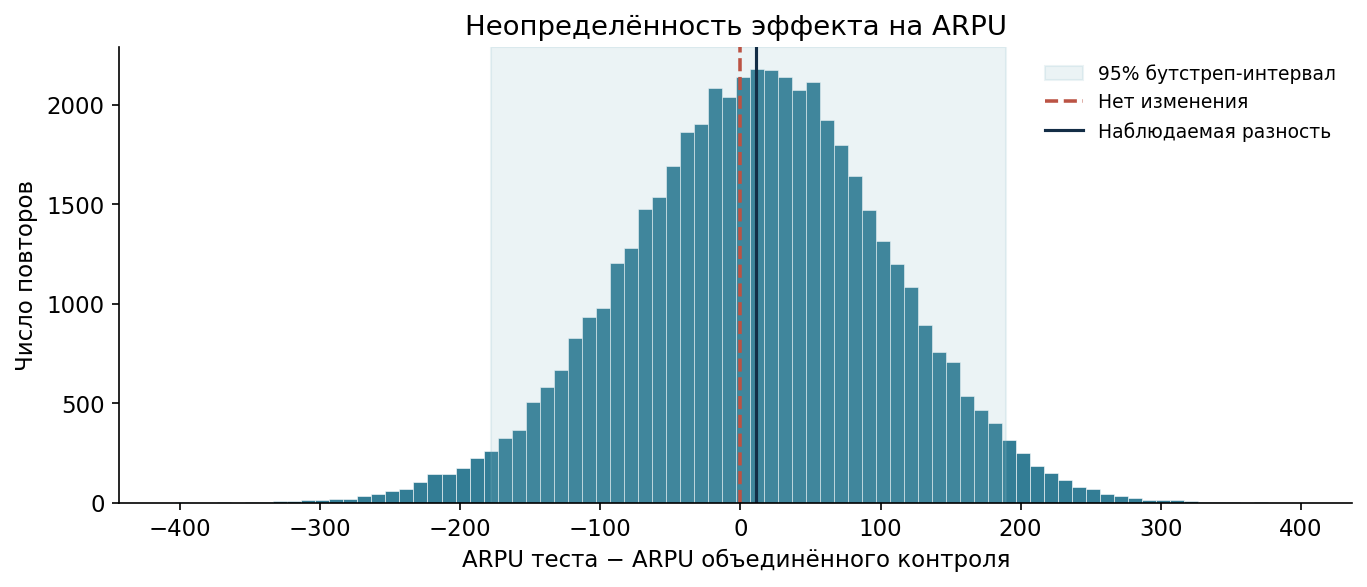

In [10]:
fig, ax = plt.subplots(figsize=(9, 3.8), constrained_layout=True)
ax.hist(boot_difference, bins=80, color='#176b87', alpha=.88, edgecolor='white', linewidth=.3)
ax.axvspan(*bootstrap_abs_ci, color='#85b8c4', alpha=.16, label='95% бутстреп-интервал')
ax.axvline(0, color='#bb5344', linestyle='--', linewidth=1.7, label='Нет изменения')
ax.axvline(primary['delta'], color='#132d46', linewidth=1.5, label='Наблюдаемая разность')
ax.set(title='Неопределённость эффекта на ARPU',
       xlabel='ARPU теста − ARPU объединённого контроля', ylabel='Число повторов')
ax.legend(frameon=False, fontsize=9)
plt.show()

In [11]:
def wilson_interval(successes, n, alpha=ALPHA):
    z = stats.norm.ppf(1-alpha/2)
    p = successes/n
    denominator = 1+z*z/n
    center = (p+z*z/(2*n))/denominator
    half = z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/denominator
    return center-half, center+half

def binary_result(x, y):
    x, y = np.asarray(x, dtype=bool), np.asarray(y, dtype=bool)
    p1, p0 = x.mean(), y.mean()
    l1, u1 = wilson_interval(x.sum(), len(x))
    l0, u0 = wilson_interval(y.sum(), len(y))
    # Интервал Ньюкомба для разности двух долей, в процентных пунктах.
    low = (p1-p0-np.sqrt((p1-l1)**2+(u0-p0)**2))*100
    high = (p1-p0+np.sqrt((u1-p1)**2+(p0-l0)**2))*100
    pvalue = stats.fisher_exact([[x.sum(), (~x).sum()],
                                 [y.sum(), (~y).sum()]]).pvalue
    return {'test': p1*100, 'control': p0*100, 'delta': (p1-p0)*100,
            'lift_pct': (p1/p0-1)*100, 'ci_low': low, 'ci_high': high,
            'p': float(pvalue)}

secondary_rows = []
for name, column in [('CR оплаты', 'payer'), ('CR premium', 'premium'),
                     ('CR premium_no_trial', 'direct'), ('CR trial_premium', 'trial')]:
    secondary_rows.append({'Метрика': name, 'Единица разности': 'п.п.',
                           **binary_result(test[column], control[column])})
secondary_rows.append({'Метрика': 'ARPPU', 'Единица разности': 'норм. ед.',
    **welch_result(test.loc[test.payer, 'total_revenue'],
                   control.loc[control.payer, 'total_revenue'])})
secondary_rows.append({'Метрика': 'Premium ARPU', 'Единица разности': 'норм. ед.',
    **welch_result(test.premium_revenue, control.premium_revenue)})
secondary = pd.DataFrame(secondary_rows)
secondary['p_holm'] = holm_adjust(secondary.p)
secondary['Значимо после Холма'] = secondary.p_holm.lt(ALPHA)
display(secondary.rename(columns={
    'test': 'Тест', 'control': 'Контроль', 'delta': 'Разность', 'lift_pct': 'Изменение, %',
    'ci_low': '95% ДИ, низ', 'ci_high': '95% ДИ, верх', 'p': 'p-value', 'p_holm': 'p Holm'
}))

,Метрика,Единица разности,Тест,Контроль,Разность,"Изменение, %","95% ДИ, низ","95% ДИ, верх",p-value,p Holm,Значимо после Холма
0,CR оплаты,п.п.,3.3890,4.3938,-1.0048,-22.8679,-1.6801,-0.2901,0.0061,0.0304,True
1,CR premium,п.п.,2.9480,3.7313,-0.7833,-20.9917,-1.4107,-0.1158,0.0217,0.0870,False
2,CR premium_no_trial,п.п.,1.5552,2.3364,-0.7811,-33.4339,-1.2548,-0.2699,0.0032,0.0190,True
3,CR trial_premium,п.п.,1.4160,1.3949,0.0211,1.5133,-0.3918,0.4798,0.9368,1.0000,False
4,ARPPU,норм. ед.,"15,759.0274","11,909.2037","3,849.8237",32.3265,-112.7088,"7,812.3562",0.0568,0.1705,False
5,Premium ARPU,норм. ед.,373.9341,341.8306,32.1034,9.3916,-74.8479,139.0548,0.5563,1.0000,False


Для долей используется двусторонний точный тест Фишера; для разностей долей
показаны интервалы Ньюкомба на основе интервалов Уилсона. Все 95% интервалы
в таблице индивидуальные, без поправки на множественные проверки;
решение о значимости дополнительных метрик принимается по `p Holm`.

- **CR оплаты:** 3,39% против 4,39%; −1,00 п.п., или −22,87%.
  p = 0,0061; после Холма p = 0,0304. Снижение статистически значимо.
- **CR premium_no_trial:** 1,56% против 2,34%; −0,78 п.п., или −33,43%.
  После Холма p = 0,0190. Снижение статистически значимо.
- **Общая CR premium:** 2,95% против 3,73%; −0,78 п.п.
  После Холма p = 0,0870 — значимость не подтверждается.
- **CR trial_premium:** 1,42% против 1,39%; после Холма p = 1,000.
- **ARPPU:** 15 759,03 против 11 909,20; +32,33%,
  но после Холма p = 0,1705.
- **Premium ARPU:** +9,39%; после Холма p = 1,000.

По метке `trial_premium` нельзя отдельно восстановить переход из пробного
периода в платную подписку: отсутствует полная история запуска trial,
продлений и отмен. `was_premium` эту историю не заменяет.

In [12]:
# Дополнительные сравнения с каждым контролем: одна семья из четырёх тестов.
pair_rows = []
for g in ['control_1', 'control_2']:
    c = users.loc[users.group.eq(g)]
    for metric, result in [
        ('ARPU', welch_result(test.total_revenue, c.total_revenue)),
        ('CR оплаты', binary_result(test.payer, c.payer))
    ]:
        pair_rows.append({'Контроль': g, 'Метрика': metric, **result})
pairwise = pd.DataFrame(pair_rows)
pairwise['p_holm'] = holm_adjust(pairwise.p)
display(pairwise[['Контроль', 'Метрика', 'delta', 'lift_pct', 'p', 'p_holm']].rename(
    columns={'delta': 'Разность (ARPU / п.п.)', 'lift_pct': 'Изменение, %',
             'p': 'p-value', 'p_holm': 'p Holm'}))

,Контроль,Метрика,Разность (ARPU / п.п.),"Изменение, %",p-value,p Holm
0,control_1,ARPU,-60.8127,-10.2225,0.6603,0.6603
1,control_1,CR оплаты,-1.0129,-23.0102,0.0168,0.0671
2,control_2,ARPU,83.6962,18.5833,0.2937,0.5875
3,control_2,CR оплаты,-0.9965,-22.7226,0.0188,0.0671


При отдельных сравнениях рост ARPU не подтверждается ни относительно
`control_1`, ни относительно `control_2`. Конверсия в оплату ниже обоих контролей;
в семье четырёх попарных проверок p после Холма = 0,0671, поэтому эти
попарные различия не называем статистически значимыми. Основная оценка снижения
конверсии относится к сравнению с объединённым контролем.

## 6. Проверки устойчивости и ограничения

Проверяем альтернативные источники выручки и обработку спорных записей.
Порогов, выбранных ради получения значимости, не используем. Удаление
крупнейшего покупателя — только диагностика его влияния. Каждый сценарий
меняет измерение или состав данных и не заменяет основной результат.

In [13]:
def sensitivity_row(label, frame, revenue):
    d = frame[['uid', 'group']].copy()
    d['rev'] = np.asarray(revenue, dtype=float)
    x = d.loc[d.group.eq('test'), 'rev']
    y = d.loc[d.group.ne('test'), 'rev']
    r = welch_result(x, y)
    cr = binary_result(x.gt(0), y.gt(0))
    return {'Сценарий': label, 'n тест': len(x), 'n контроль': len(y),
            'ARPU тест': x.mean(), 'ARPU контроль': y.mean(),
            'Изменение ARPU, %': r['lift_pct'], 'p ARPU': r['p'],
            'Δ CR, п.п.': cr['delta'], 'p CR': cr['p']}

sensitivity_rows = [sensitivity_row('Основной: users.total_revenue', users, users.total_revenue)]
sensitivity_rows.append(sensitivity_row('С историческим пользователем', users_all, users_all.total_revenue))
sensitivity_rows.append(sensitivity_row(
    'Выручка по всем транзакциям', users, users.uid.map(tx_revenue).fillna(0)))
deduplicated = transactions.drop_duplicates(subset=transaction_columns)
sensitivity_rows.append(sensitivity_row(
    'Транзакции без полных повторов', users,
    users.uid.map(deduplicated.groupby('uid').revenue.sum()).fillna(0)))
without_mismatches = users.loc[~users.uid.isin(mismatches.uid)]
sensitivity_rows.append(sensitivity_row(
    'Без двух несогласованных uid', without_mismatches, without_mismatches.total_revenue))
largest_uid = int(users.loc[users.total_revenue.idxmax(), 'uid'])
without_largest = users.loc[users.uid.ne(largest_uid)]
sensitivity_rows.append(sensitivity_row(
    'Без крупнейшего плательщика', without_largest, without_largest.total_revenue))
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity)

,Сценарий,n тест,n контроль,ARPU тест,ARPU контроль,"Изменение ARPU, %",p ARPU,"Δ CR, п.п.",p CR
0,Основной: users.total_revenue,4308,8603,534.0803,523.2685,2.0662,0.9075,-1.0048,0.0061
1,С историческим пользователем,4308,8604,534.0803,523.2107,2.0775,0.9070,-1.0159,0.0061
2,Выручка по всем транзакциям,4308,8603,544.3131,526.7864,3.3271,0.8521,-1.0164,0.0061
3,Транзакции без полных повторов,4308,8603,541.3709,511.6814,5.8024,0.7355,-1.0164,0.0061
4,Без двух несогласованных uid,4307,8602,530.7483,523.3293,1.4176,0.9364,-1.0277,0.0052
5,Без крупнейшего плательщика,4308,8602,534.0803,466.7925,14.4149,0.3625,-0.9937,0.0069


Во всех показанных сценариях значимого роста ARPU нет. Даже без крупнейшего
покупателя в первом контроле рост составляет +14,41% при p = 0,363.
Направление снижения конверсии сохраняется. p-value сценариев являются
диагностическими; это не независимые подтверждения эффекта.

Ограничения, влияющие на решение:

- В условии не перечислены страны и коды двух платёжных систем,
  для которых менялась цена. Нельзя достоверно восстановить охват изменения
  или его эффект только на затронутых пользователях. Покупателей конкретной
  системы нельзя использовать вместо всех назначенных в неё пользователей.
- Нет времени назначения в группу, единого конца наблюдения и регистраций
  неплатящих пользователей. Полноту рандомизации и равенство окна наблюдения
  по выгрузке установить нельзя.
- Нет надёжного уникального ключа транзакции и объяснения расхождений
  двух источников выручки. Влияние этих расхождений проверено сценариями.
- Выручка зависит от нескольких крупных плательщиков. Доверительный интервал
  основного эффекта широкий; отсутствие значимости не означает отсутствия эффекта.
- Нет себестоимости, комиссий, отмен подписки и полноценной истории продлений.
  Результат относится к наблюдаемой выручке, а не прибыли или долгосрочному LTV.

## 7. Ответ на вопрос проекта

**Признать эксперимент успешным нельзя.**

1. Основная метрика ARPU выросла с 523,27 до 534,08: **+2,07%**, p = **0,907**.
   Статистически подтверждённого улучшения нет.
2. Конверсия в оплату снизилась с **4,39% до 3,39%**:
   **−1,00 п.п. / −22,87%**, p после поправки Холма = **0,0304**.
   Снизилась и конверсия в `premium_no_trial`.
3. Более высокий доход на плательщика не обеспечивает доказанного роста
   дохода на всех пользователей. Вывод о неподтверждённом росте ARPU
   сохраняется при альтернативной обработке спорных данных.

**Решение:** не внедрять изменение по результатам этой выгрузки.
Для повторной оценки нужны подтверждённые правила участия в тесте,
исправленные даты и платежи, одинаковое окно наблюдения для всех пользователей
и данные о продлениях. Длительность нового эксперимента следует рассчитать
по заранее выбранному минимально полезному росту ARPU и допустимому снижению CR.